<a href="https://colab.research.google.com/github/cabamarcos/CIFAR10_CNN/blob/main/muinar06_act2_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
from tensorflow.keras import K
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

Voy a cambiar la forma en la que creamos lso conjuntos de datos para ver si puedo mejorar los resultados. Actualmente los resultados me dan así:

| Modelo                  | Accuracy Test |
| ----------------------- | ------------- |
| **MLP \[256]**          | 39.63%        |
| **MLP \[512,128]**      | 41.84%        |
| **MLP \[1024,512,128]** | 43.66%        |
| **CNN 1 capa**          | 64.36%        |
| **CNN 2 capas**         | 67.91%        |
| **CNN 3 capas**         | 65.32%        |
| **CNN 4 capas**         | 71.89%        |
| **ALEXNET**             | 77.50%        |

In [2]:
# # Primero, definimos los datos de entrenamiento, validación y prueba
# (X, Y), (x_test, y_test) = cifar10.load_data()
# (x_train, x_valid) = (X[:40000], X[40000:])
# (y_train, y_valid) = (Y[:40000], Y[40000:])

# # Normalizamos como de costumbre
# x_train = x_train / 255.
# x_valid = x_valid / 255.
# x_test = x_test / 255.

# # Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# # La incluimos para ayudarte con la identificación de clases. De ti depende
# # si quieres utilizar esta variable o no
# MAP_ELEMENTS = {
#     0: 'avion', 1: 'coche', 2: 'ave',
#     3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
#     7: 'caballo', 8: 'barco', 9: 'camion'
# }

# # Función auxiliar para convertir las etiquetas a codificación one-hot
# def convert_to_one_hot(labels, num_classes):
#     return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# # Convertimos las etiquetas de entrenamiento, validación y prueba
# num_classes = 10
# y_train_one_hot = convert_to_one_hot(y_train, num_classes)
# y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
# y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# # Verificamos las conversiones
# print(y_train_one_hot.shape)
# print(y_valid_one_hot.shape)
# print(y_test_one_hot.shape)

In [3]:
(X, Y), (x_test, y_test) = cifar10.load_data()

X = X.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train, x_valid, y_train, y_valid = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

In [4]:
num_classes = 10
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

x_train: (40000, 32, 32, 3)
x_valid: (10000, 32, 32, 3)
x_test: (10000, 32, 32, 3)


Usamos data augmentation para crear más imágenes para el entrenamiento

In [5]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

train_generator = train_datagen.flow(x_train, y_train_one_hot, batch_size=64)

## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

## Análisis exploratorio de los datos

Primero vamos a ver el tamaño de los datasets y las imágenes

In [6]:
print("Tamaño de una imagen (altura, anchura, canales):", x_train[0].shape)

print("Forma del conjunto de entrenamiento:", x_train.shape)
print("Forma del conjunto de validación:", x_valid.shape)
print("Forma del conjunto de test:", x_test.shape)


Tamaño de una imagen (altura, anchura, canales): (32, 32, 3)
Forma del conjunto de entrenamiento: (40000, 32, 32, 3)
Forma del conjunto de validación: (10000, 32, 32, 3)
Forma del conjunto de test: (10000, 32, 32, 3)


En la siguiente celda vamos a ver la primera imágen de cada clase del dataset

<ipython-input-7-38e3afeaa2fe>:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(y_train[i])


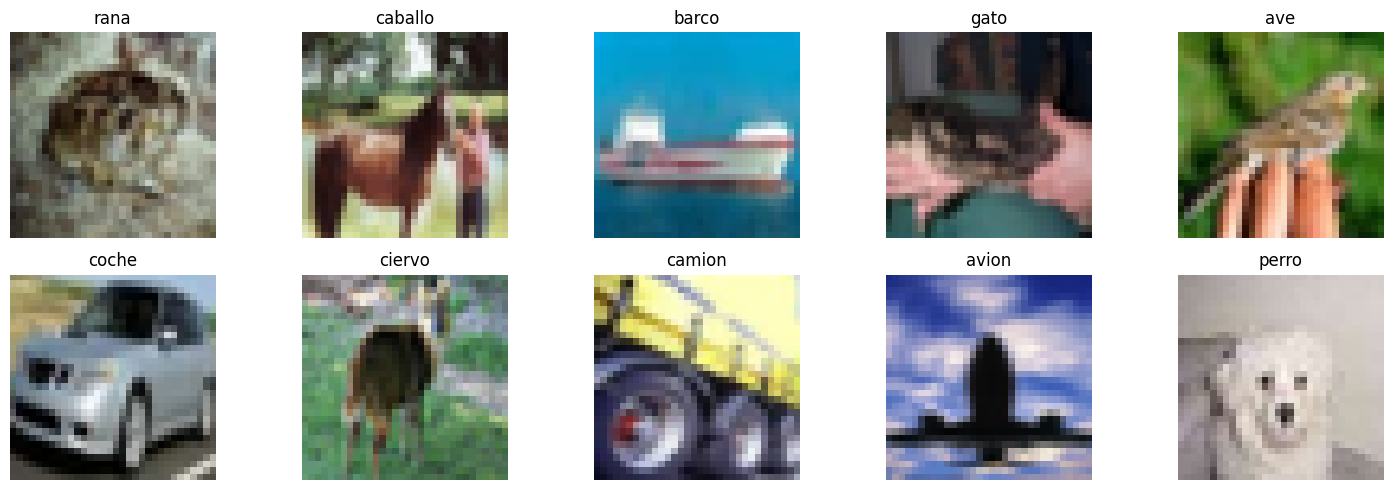

In [7]:
samples = {}
for i in range(len(y_train)):
    label = int(y_train[i])
    if label not in samples:
        samples[label] = x_train[i]
    if len(samples) == 10:
        break

plt.figure(figsize=(15, 5))
for idx, (label, image) in enumerate(samples.items()):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(image)
    plt.title(MAP_ELEMENTS[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

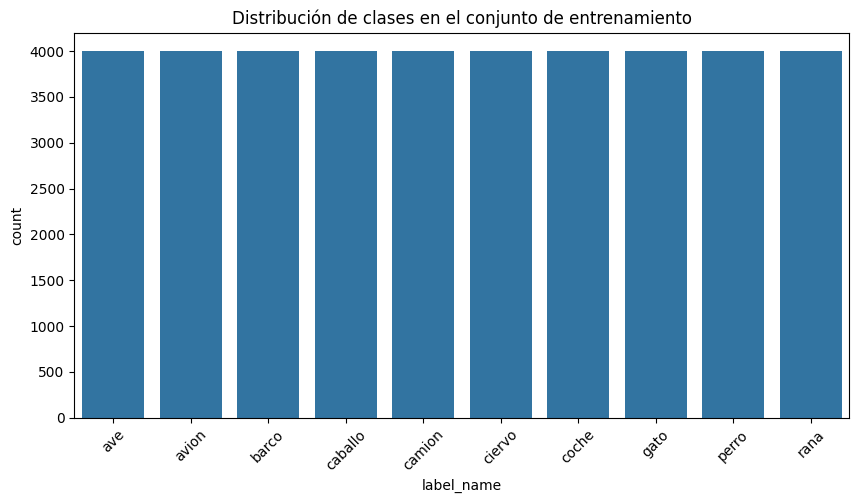

In [8]:
df_labels = pd.DataFrame(y_train, columns=['label'])
df_labels['label_name'] = df_labels['label'].map(MAP_ELEMENTS)

# Gráfico de conteo
plt.figure(figsize=(10, 5))
sns.countplot(x='label_name', data=df_labels, order=sorted(MAP_ELEMENTS.values()))
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xticks(rotation=45)
plt.show()


Como podemos ver, el dataset está muy balanceado, por lo que no habrá que tomar ninguna medida respecto a esto

## Modelos

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

### Perceptrón multicapa

Ya sabemos que un perceptrón multicapa no va a poder tener muy buenos resultados en un dataset con imágenes algo complejas. Vamos a ver los resultados para luego poder compararlo con los modelos de redes convolucionales.

En estos modelos no usaremos data augmentation, ya que los MLP no entienden estructuras espaciales, por lo que no tiene sentido cambiar una imagen para entrenar un MLP con ella.

In [ ]:
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_valid_flat = x_valid.reshape((x_valid.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

model_configs = [
    [256],
    [512, 128],
    [1024, 512, 128]
]


Entrenando MLP con arquitectura: [256]
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2156 - loss: 2.1786 - val_accuracy: 0.3415 - val_loss: 1.8718
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2837 - loss: 1.9413 - val_accuracy: 0.3348 - val_loss: 1.8283
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3081 - loss: 1.8881 - val_accuracy: 0.3732 - val_loss: 1.7633
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3220 - loss: 1.8526 - val_accuracy: 0.3798 - val_loss: 1.7462
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3248 - loss: 1.8444 - val_accuracy: 0.3599 - val_loss: 1.7822
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3256 - loss: 1.8434 - val_accuracy: 0.3704 - val_loss: 1.7680
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3333 - loss: 1.8288 - val_accuracy: 0.3885 - val_loss: 1.7282
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 

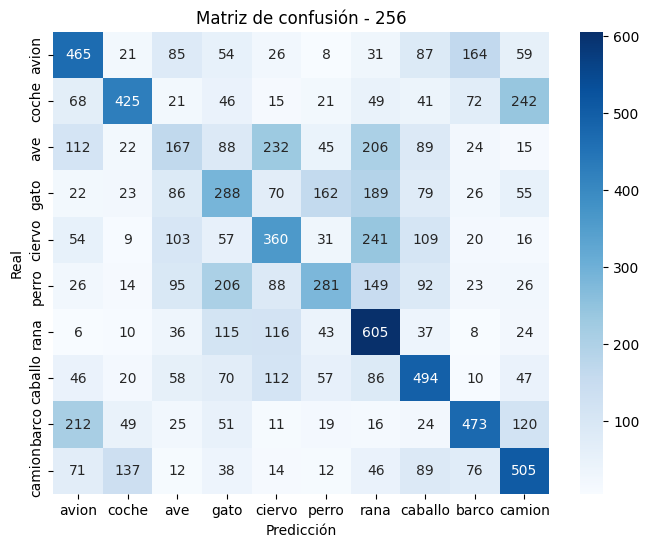


Entrenando MLP con arquitectura: [512, 128]
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1937 - loss: 2.2086 - val_accuracy: 0.3036 - val_loss: 1.9180
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2892 - loss: 1.9348 - val_accuracy: 0.3511 - val_loss: 1.8273
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3028 - loss: 1.8950 - val_accuracy: 0.3679 - val_loss: 1.7741
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3268 - loss: 1.8426 - val_accuracy: 0.3728 - val_loss: 1.7780
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3342 - loss: 1.8208 - val_accuracy: 0.3733 - val_loss: 1.7559
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3427 - loss: 1.8013 - val_accuracy: 0.3962 - val_loss: 1.7088
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3486 - loss: 1.7803 - val_accuracy: 0.4031 - val_loss: 1.7024
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accur

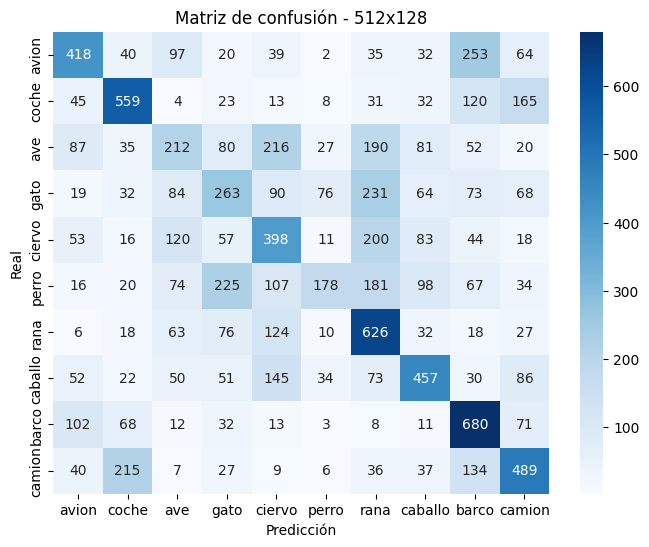


Entrenando MLP con arquitectura: [1024, 512, 128]
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1422 - loss: 2.3117 - val_accuracy: 0.2602 - val_loss: 1.9683
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2662 - loss: 1.9702 - val_accuracy: 0.3217 - val_loss: 1.8822
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2864 - loss: 1.9319 - val_accuracy: 0.3444 - val_loss: 1.8447
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3037 - loss: 1.8803 - val_accuracy: 0.3425 - val_loss: 1.8471
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3140 - loss: 1.8652 - val_accuracy: 0.3510 - val_loss: 1.8127
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3212 - loss: 1.8546 - val_accuracy: 0.3524 - val_loss: 1.8228
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3292 - loss: 1.8312 - val_accuracy: 0.3583 - val_loss: 1.7925
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step -

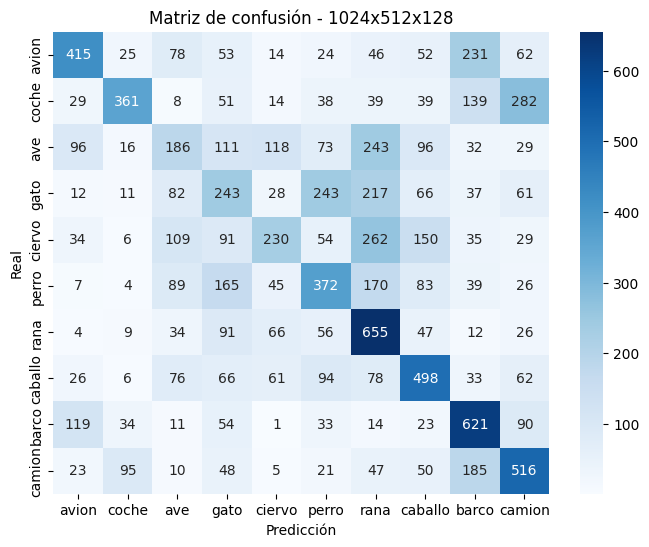

In [ ]:
results = []

for config in model_configs:
    model_name = 'x'.join(map(str, config))
    print(f"\nEntrenando MLP con arquitectura: {config}")

    model = Sequential()
    model.add(Input(shape=(x_train_flat.shape[1],)))

    for units in config:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.3))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train_flat, y_train_one_hot,
                        validation_data=(x_valid_flat, y_valid_one_hot),
                        callbacks=[early_stop],
                        epochs=50, batch_size=64, verbose=1)

    # Evaluación
    y_pred_probs = model.predict(x_test_flat)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_one_hot, axis=1)

    # Calcular accuracy global en test
    test_accuracy = accuracy_score(y_true, y_pred)

    # Reporte de métricas por clase
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    class_metrics = df_report.loc[:'9'][['precision', 'recall']]
    class_metrics.index = [MAP_ELEMENTS[int(i)] for i in class_metrics.index]

    # Guardar resultados
    results.append((model_name, class_metrics, test_accuracy))

    # Matriz de confusión
    print(f"\nMatriz de confusión para modelo {config}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=MAP_ELEMENTS.values(),
                yticklabels=MAP_ELEMENTS.values())
    plt.title(f'Matriz de confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


In [ ]:
for name, metrics_df, acc in results:
    print(f"\n=== Modelo {name} ===")
    print(f"Accuracy global en test: {acc*100:.2f}%")
    print(metrics_df.round(3).to_string())


=== Modelo 256 ===
Accuracy global en test: 40.63%
         precision  recall
avion        0.430   0.465
coche        0.582   0.425
ave          0.243   0.167
gato         0.284   0.288
ciervo       0.345   0.360
perro        0.414   0.281
rana         0.374   0.605
caballo      0.433   0.494
barco        0.528   0.473
camion       0.455   0.505

=== Modelo 512x128 ===
Accuracy global en test: 42.80%
         precision  recall
avion        0.499   0.418
coche        0.545   0.559
ave          0.293   0.212
gato         0.308   0.263
ciervo       0.345   0.398
perro        0.501   0.178
rana         0.389   0.626
caballo      0.493   0.457
barco        0.462   0.680
camion       0.469   0.489

=== Modelo 1024x512x128 ===
Accuracy global en test: 40.97%
         precision  recall
avion        0.542   0.415
coche        0.637   0.361
ave          0.272   0.186
gato         0.250   0.243
ciervo       0.395   0.230
perro        0.369   0.372
rana         0.370   0.655
caballo      0.451   

Como podemos ver hay accuraccy que ronda el 40%, por lo que podemos decir que los modelos son muy malos. Podemos ver que aumentar la profundidad y el número de neuronas por en las capas no mejora significativamente el modelo. Vamos a realizar unas pruebas con redes convolucionales.

### Redes convolucionales

#### Experimentos

In [ ]:
cnn_configs = {
    'CNN_1conv': 1,
    'CNN_2conv': 2,
    'CNN_3conv': 3,
    'CNN_4conv': 4
}


Entrenando modelo: CNN_1conv

Resumen del modelo CNN_1conv:


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,018 (4.01 MB)

 Trainable params: 1,050,954 (4.01 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.2827 - loss: 2.0179 - val_accuracy: 0.4462 - val_loss: 1.5552
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.3959 - loss: 1.6481 - val_accuracy: 0.4972 - val_loss: 1.4551
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4292 - loss: 1.5655 - val_accuracy: 0.5142 - val_loss: 1.3530
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.4522 - loss: 1.5130 - val_accuracy: 0.5134 - val_loss: 1.3176
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - accuracy: 0.4705 - loss: 1.4718 - val_accuracy: 0.5279 - val_loss: 1.3380
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.4790 - loss: 1.4513 - val_accuracy: 0.5386 - val_loss: 1.3392
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.4900 - loss: 1.4197 - val_accuracy: 0.5720 - val_loss: 1.2030
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4996 - loss: 1.4032 - 

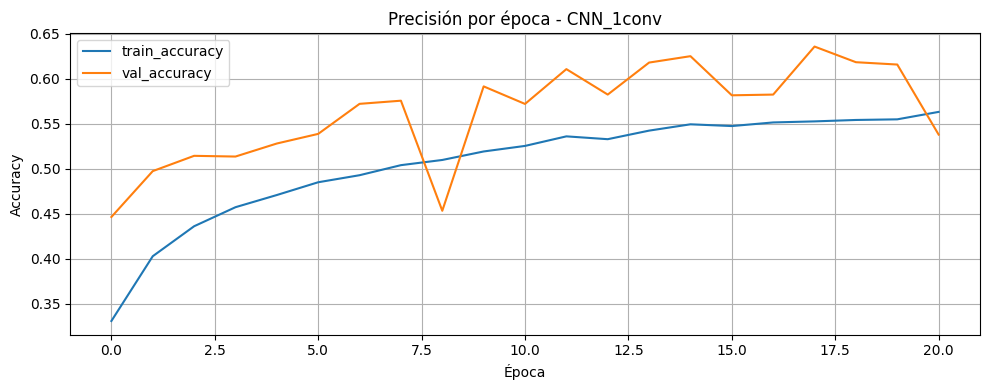

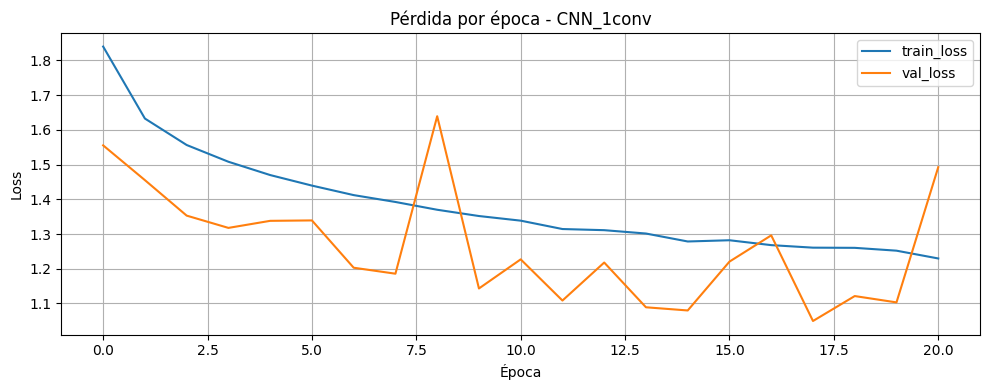

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Matriz de confusión para CNN_1conv


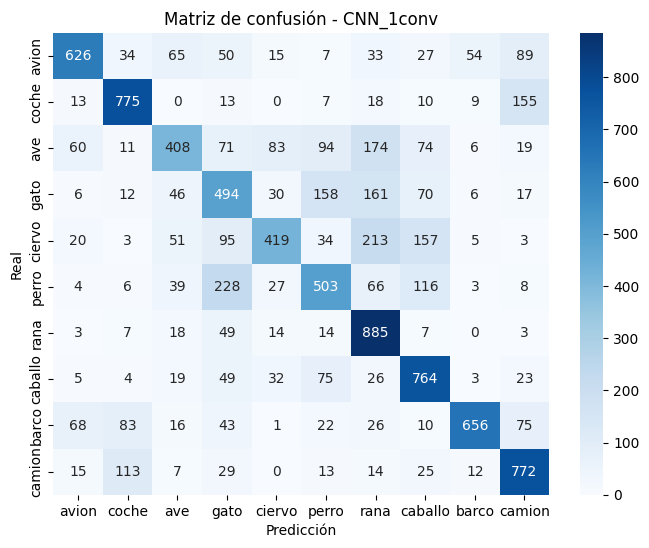


Entrenando modelo: CNN_2conv

Resumen del modelo CNN_2conv:


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.2785 - loss: 2.0650 - val_accuracy: 0.4535 - val_loss: 1.4970
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.4067 - loss: 1.6418 - val_accuracy: 0.5249 - val_loss: 1.3862
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.4630 - loss: 1.4977 - val_accuracy: 0.5438 - val_loss: 1.3215
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.5016 - loss: 1.3942 - val_accuracy: 0.5617 - val_loss: 1.2618
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.5283 - loss: 1.3288 - val_accuracy: 0.6397 - val_loss: 1.0271
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.5510 - loss: 1.2747 - val_accuracy: 0.6203 - val_loss: 1.0690
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.5600 - loss: 1.2370 - val_accuracy: 0.6392 - val_loss: 1.0205
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.5777 - loss: 1.1981 - 

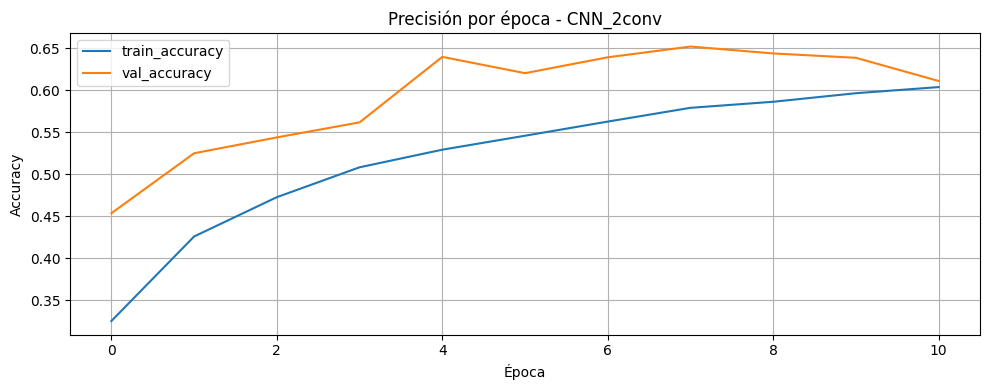

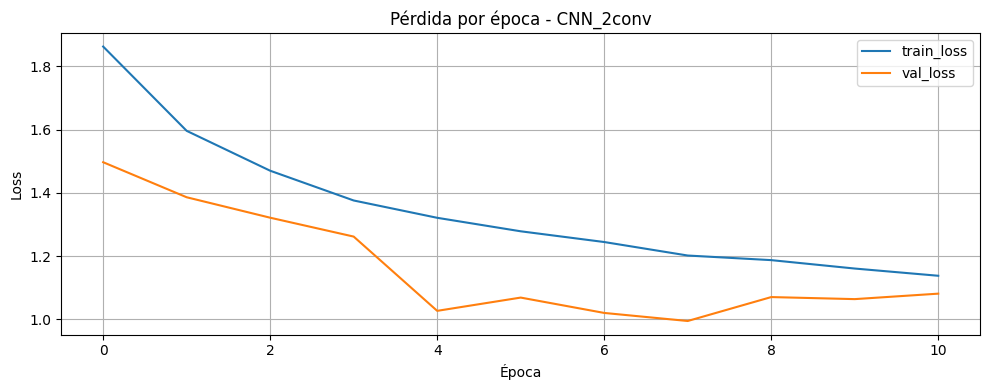

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Matriz de confusión para CNN_2conv


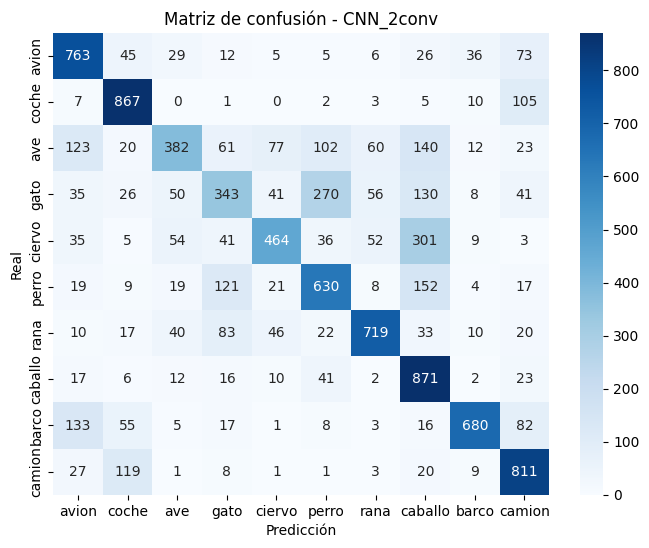


Entrenando modelo: CNN_3conv

Resumen del modelo CNN_3conv:


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.2943 - loss: 2.0404 - val_accuracy: 0.4848 - val_loss: 1.4261
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - accuracy: 0.4509 - loss: 1.5358 - val_accuracy: 0.4716 - val_loss: 1.5013
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.5112 - loss: 1.3728 - val_accuracy: 0.5798 - val_loss: 1.2050
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.5572 - loss: 1.2576 - val_accuracy: 0.6564 - val_loss: 0.9651
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.5855 - loss: 1.1607 - val_accuracy: 0.6760 - val_loss: 0.9412
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.6163 - loss: 1.0983 - val_accuracy: 0.6758 - val_loss: 0.9372
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.6375 - loss: 1.0525 - val_accuracy: 0.6563 - val_loss: 1.0433
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.6510 - loss: 1.0114 - 

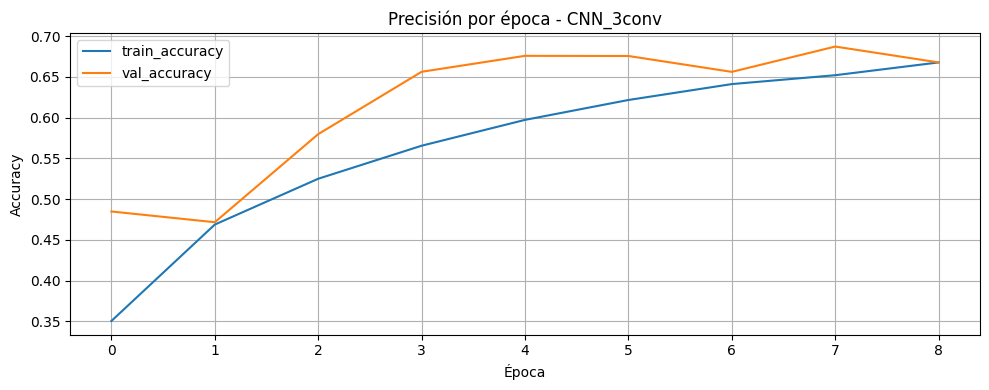

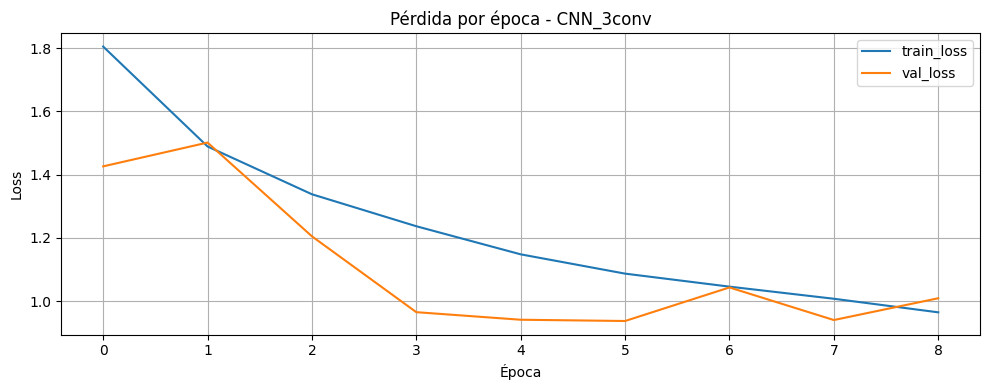

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Matriz de confusión para CNN_3conv


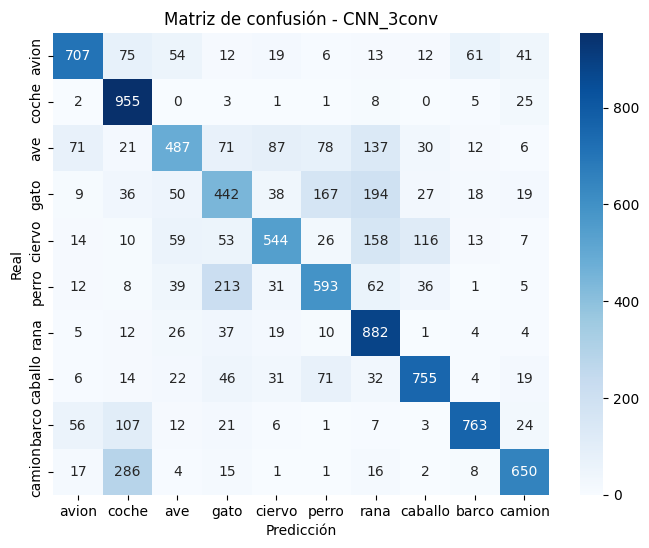


Entrenando modelo: CNN_4conv

Resumen del modelo CNN_4conv:


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,826 (1.99 MB)

 Trainable params: 521,866 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - accuracy: 0.2990 - loss: 2.0165 - val_accuracy: 0.5171 - val_loss: 1.3386
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.4589 - loss: 1.4899 - val_accuracy: 0.5101 - val_loss: 1.3632
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.5354 - loss: 1.3069 - val_accuracy: 0.5430 - val_loss: 1.2927
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.5821 - loss: 1.1795 - val_accuracy: 0.6672 - val_loss: 0.9663
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.6251 - loss: 1.0839 - val_accuracy: 0.4200 - val_loss: 2.0375
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.6568 - loss: 1.0058 - val_accuracy: 0.6428 - val_loss: 1.1121
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.6789 - loss: 0.9427 - val_accuracy: 0.6835 - val_loss: 0.9004
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6959 - loss: 0.8935 - 

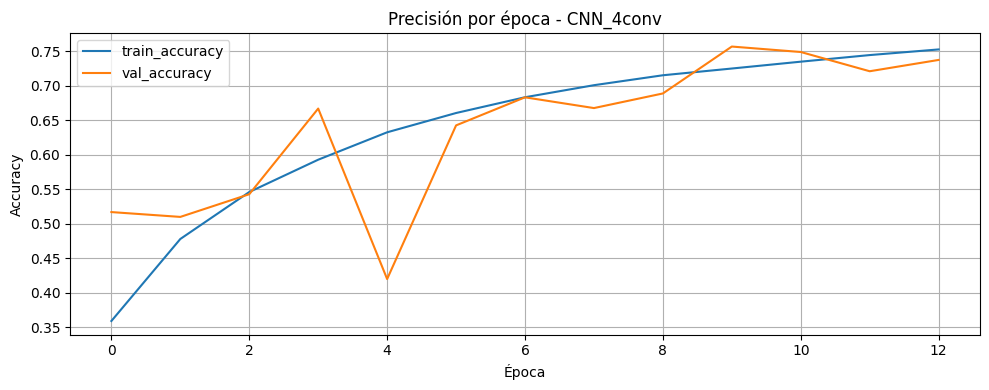

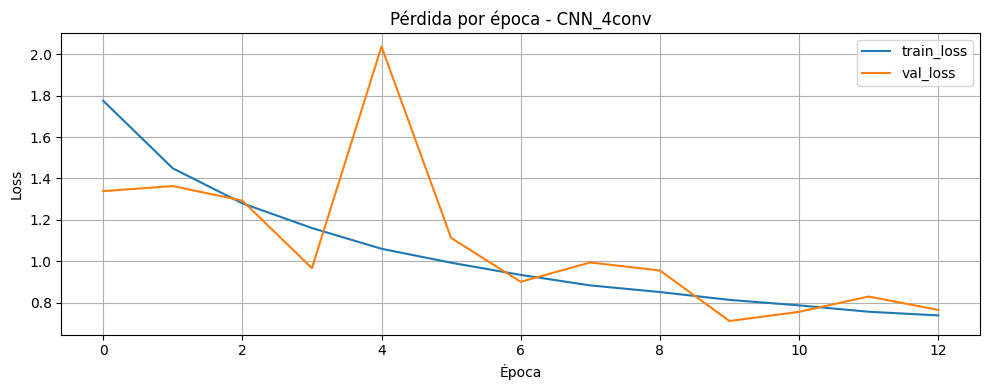

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Matriz de confusión para CNN_4conv


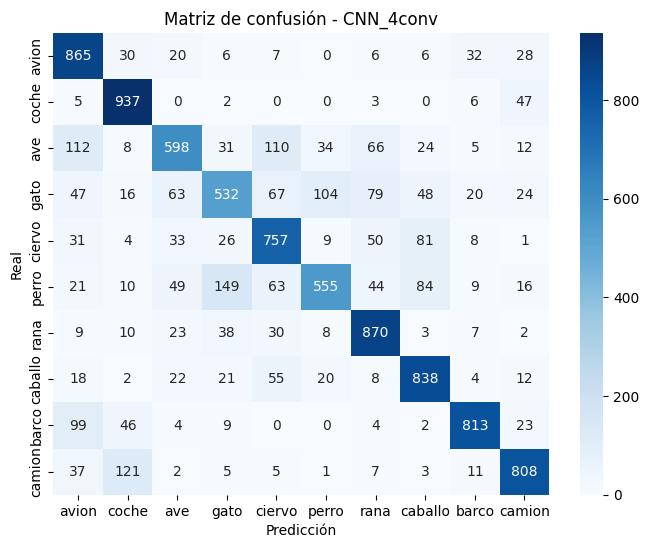

In [ ]:
results = []

for name, num_convs in cnn_configs.items():
    print(f"\nEntrenando modelo: {name}")

    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))

    filters = 32
    for i in range(num_convs):
        model.add(Conv2D(filters, (3, 3), activation='relu', padding='same'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        filters *= 2  # Duplicar filtros cada capa

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    print(f"\nResumen del modelo {name}:")
    model.summary()

    history = model.fit(train_generator,
                        validation_data=(x_valid, y_valid_one_hot),
                        epochs=30,
                        batch_size=64,
                        callbacks=[early_stop],
                        verbose=1)

    # Graficar precisión
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(f'Precisión por época - {name}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graficar pérdida
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'Pérdida por época - {name}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # Evaluación
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_one_hot, axis=1)

    # Accuracy
    test_acc = accuracy_score(y_true, y_pred)

    # Métricas por clase
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    class_metrics = df_report.loc[:'9'][['precision', 'recall']]
    class_metrics.index = [MAP_ELEMENTS[int(i)] for i in class_metrics.index]

    results.append((name, class_metrics, test_acc))

    # Matriz de confusión
    print(f"\nMatriz de confusión para {name}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=MAP_ELEMENTS.values(),
                yticklabels=MAP_ELEMENTS.values())
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


In [ ]:
for name, metrics_df, acc in results:
    print(f"\n=== Modelo {name} ===")
    print(f"Accuracy global en test: {acc*100:.2f}%")
    print(metrics_df.round(3).to_string())



=== Modelo CNN_1conv ===
Accuracy global en test: 63.02%
         precision  recall
avion        0.763   0.626
coche        0.740   0.775
ave          0.610   0.408
gato         0.441   0.494
ciervo       0.675   0.419
perro        0.543   0.503
rana         0.548   0.885
caballo      0.606   0.764
barco        0.870   0.656
camion       0.663   0.772

=== Modelo CNN_2conv ===
Accuracy global en test: 65.30%
         precision  recall
avion        0.653   0.763
coche        0.742   0.867
ave          0.645   0.382
gato         0.488   0.343
ciervo       0.697   0.464
perro        0.564   0.630
rana         0.788   0.719
caballo      0.514   0.871
barco        0.872   0.680
camion       0.677   0.811

=== Modelo CNN_3conv ===
Accuracy global en test: 67.78%
         precision  recall
avion        0.786   0.707
coche        0.627   0.955
ave          0.647   0.487
gato         0.484   0.442
ciervo       0.700   0.544
perro        0.622   0.593
rana         0.584   0.882
caballo      0.7

#### AlexNet

Ahora quiero probar una arquitectura muy conocida como es alexnet, con la cual espero tener mejores resultados

In [ ]:
# AlexNet adaptado
alexnet = Sequential()

alexnet.add(Input(shape=(32, 32, 3)))

# 1ª capa conv: 64 filtros 3x3
alexnet.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# 2ª capa conv: 128 filtros 3x3
alexnet.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# 3ª, 4ª, 5ª capas conv: 256 filtros
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten + fully connected
alexnet.add(Flatten())
alexnet.add(Dense(512, activation='relu'))
alexnet.add(Dropout(0.5))
alexnet.add(Dense(512, activation='relu'))
alexnet.add(Dropout(0.5))

# Salida
alexnet.add(Dense(10, activation='softmax'))

# Compilar
alexnet.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Mostrar arquitectura
alexnet.summary()

In [ ]:
history = alexnet.fit(train_generator,
                      validation_data=(x_valid, y_valid_one_hot),
                      epochs=50,
                      batch_size=64,
                      callbacks=[early_stop],
                      verbose=1)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,920,266 (14.95 MB)

 Trainable params: 3,918,346 (14.95 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.2480 - loss: 2.3276 - val_accuracy: 0.4116 - val_loss: 1.6366
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4117 - loss: 1.6248 - val_accuracy: 0.5458 - val_loss: 1.3686
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.5104 - loss: 1.3846 - val_accuracy: 0.5813 - val_loss: 1.2754
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.5724 - loss: 1.2361 - val_accuracy: 0.6242 - val_loss: 1.1589
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.6186 - loss: 1.1206 - val_accuracy: 0.6470 - val_loss: 1.0311
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6574 - loss: 1.0274 - val_accuracy: 0.6467 - val_loss: 1.0443
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.6816 - loss: 0.9519 - val_accuracy: 0.6276 - val_loss: 1.1023
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.7054 - loss: 0.8920 - val_accurac

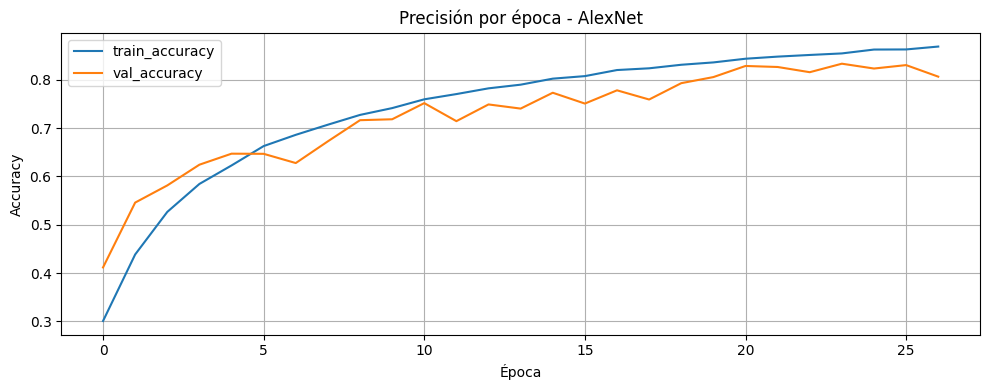

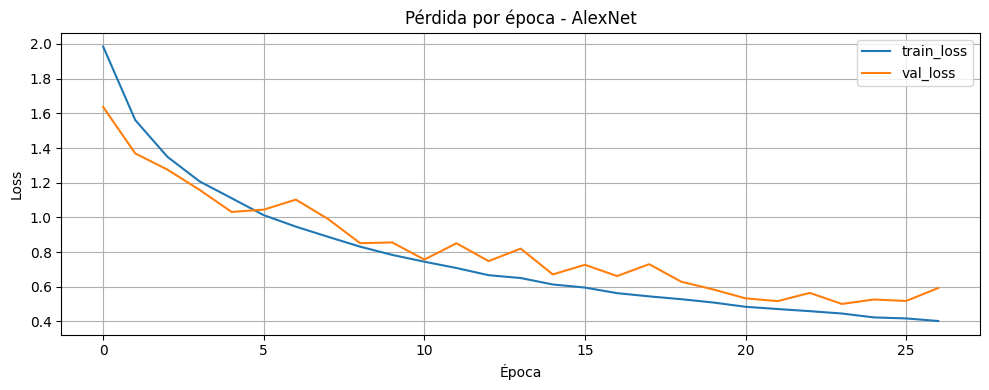

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Accuracy en test: 83.01%

=== Métricas por clase (AlexNet) ===
         precision  recall
avion        0.860   0.851
coche        0.940   0.888
ave          0.854   0.725
gato         0.653   0.700
ciervo       0.848   0.773
perro        0.783   0.756
rana         0.813   0.905
caballo      0.922   0.829
barco        0.900   0.924
camion       0.774   0.950


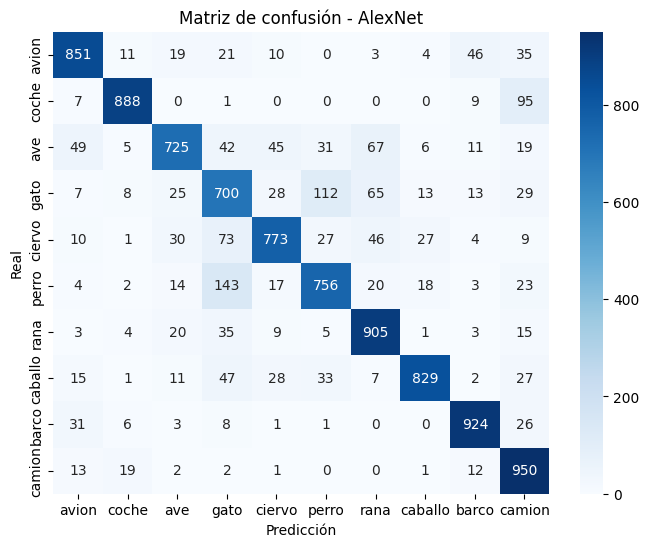

In [ ]:
# AlexNet adaptado
alexnet = Sequential()

alexnet.add(Input(shape=(32, 32, 3)))

# 1ª capa conv: 64 filtros 3x3
alexnet.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# 2ª capa conv: 128 filtros 3x3
alexnet.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# 3ª, 4ª, 5ª capas conv: 256 filtros
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten + fully connected
alexnet.add(Flatten())
alexnet.add(Dense(512, activation='relu'))
alexnet.add(Dropout(0.5))
alexnet.add(Dense(512, activation='relu'))
alexnet.add(Dropout(0.5))

# Salida
alexnet.add(Dense(10, activation='softmax'))

# Compilar
alexnet.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Mostrar arquitectura
alexnet.summary()

history = alexnet.fit(train_generator,
                      validation_data=(x_valid, y_valid_one_hot),
                      epochs=50,
                      batch_size=64,
                      callbacks=[early_stop],
                      verbose=1)

# Graficar evolución
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Precisión por época - AlexNet')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida por época - AlexNet')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluación final
y_pred_probs = alexnet.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

test_acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy en test: {test_acc * 100:.2f}%")

# Métricas por clase
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.loc[:'9'][['precision', 'recall']]
df_report.index = [MAP_ELEMENTS[int(i)] for i in df_report.index]

print("\n=== Métricas por clase (AlexNet) ===")
print(df_report.round(3).to_string())

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=MAP_ELEMENTS.values(),
            yticklabels=MAP_ELEMENTS.values())
plt.title('Matriz de confusión - AlexNet')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


#### EfficientNet

In [16]:
def MBConv(inputs, filters, kernel_size, stride, expand_ratio, se_ratio=0.25):
    input_channels = inputs.shape[-1]
    expanded = input_channels * expand_ratio

    # Expansion
    if expand_ratio != 1:
        x = Conv2D(expanded, 1, padding='same', use_bias=False)(inputs)
        x = BatchNormalization()(x)
        x = ReLU()(x)
    else:
        x = inputs

    # Depthwise conv
    x = DepthwiseConv2D(kernel_size, strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Squeeze and Excitation
    se = GlobalAveragePooling2D()(x)
    se = Dense(int(expanded * se_ratio), activation='relu')(se)
    se = Dense(expanded, activation='sigmoid')(se)
    se = Reshape((1, 1, expanded))(se)
    x = Multiply()([x, se])

    # Projection
    x = Conv2D(filters, 1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    # Skip connection
    if stride == 1 and input_channels == filters:
        x = Add()([x, inputs])

    return x

def build_efficientnet_cifar(input_shape=(32,32,3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Stem
    x = Conv2D(32, 3, strides=1, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # MBConv blocks
    x = MBConv(x, filters=16, kernel_size=3, stride=1, expand_ratio=1)
    x = MBConv(x, filters=24, kernel_size=3, stride=2, expand_ratio=6)
    x = MBConv(x, filters=24, kernel_size=3, stride=1, expand_ratio=6)
    x = MBConv(x, filters=40, kernel_size=5, stride=2, expand_ratio=6)
    x = MBConv(x, filters=40, kernel_size=5, stride=1, expand_ratio=6)

    # Head
    x = Conv2D(128, 1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_efficientnet_cifar()
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
# Entrenamiento
history = model.fit(train_generator,
                      validation_data=(x_valid, y_valid_one_hot),
                      epochs=100,
                      batch_size=32,
                      callbacks=[early_stop],
                      verbose=1)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 64ms/step - accuracy: 0.3541 - loss: 1.7488 - val_accuracy: 0.4404 - val_loss: 1.6251
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.5671 - loss: 1.2073 - val_accuracy: 0.5480 - val_loss: 1.3421
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.6389 - loss: 1.0171 - val_accuracy: 0.6600 - val_loss: 0.9603
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6735 - loss: 0.9252 - val_accuracy: 0.7044 - val_loss: 0.8473
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7055 - loss: 0.8367 - val_accuracy: 0.7084 - val_loss: 0.8301
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.7292 - loss: 0.7785 - val_accuracy: 0.6710 - val_loss: 1.0591
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.7445 - loss: 0.7423 - val_accuracy: 0.7413 - val_loss: 0.7423
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.7585 - loss: 0

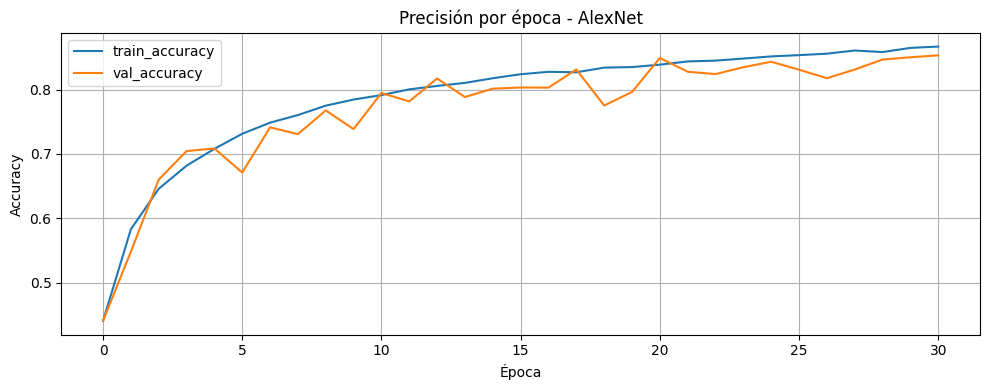

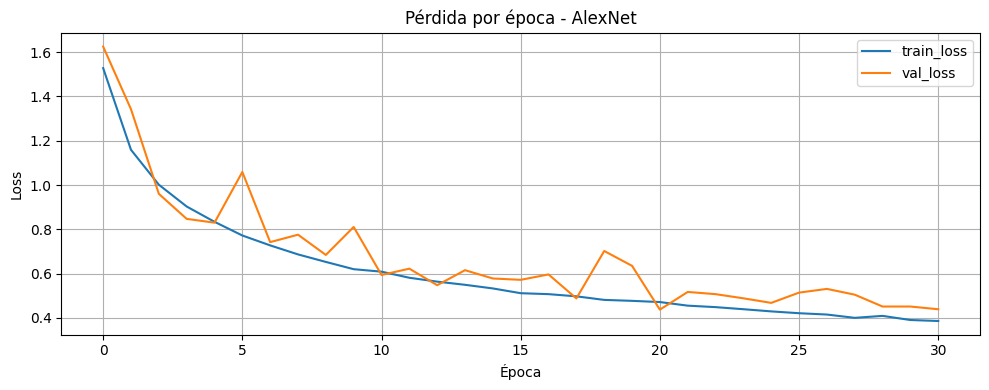

In [18]:
# Graficar evolución
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Precisión por época - AlexNet')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida por época - AlexNet')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step

Accuracy en test: 84.89%

=== Métricas por clase (AlexNet) ===
         precision  recall
avion        0.842   0.866
coche        0.904   0.946
ave          0.827   0.774
gato         0.737   0.727
ciervo       0.829   0.836
perro        0.842   0.730
rana         0.860   0.904
caballo      0.797   0.922
barco        0.936   0.896
camion       0.921   0.888


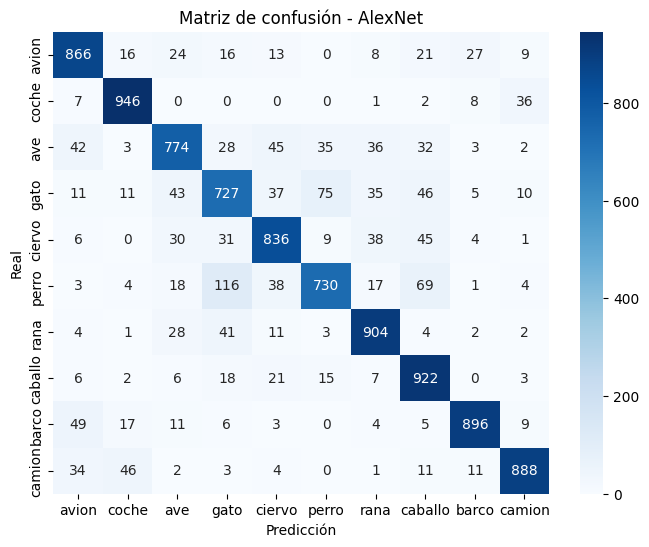

In [19]:
# Evaluación final
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

test_acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy en test: {test_acc * 100:.2f}%")

# Métricas por clase
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.loc[:'9'][['precision', 'recall']]
df_report.index = [MAP_ELEMENTS[int(i)] for i in df_report.index]

print("\n=== Métricas por clase (AlexNet) ===")
print(df_report.round(3).to_string())

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=MAP_ELEMENTS.values(),
            yticklabels=MAP_ELEMENTS.values())
plt.title('Matriz de confusión - AlexNet')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Comparación de resultados

Como podemos ver en la siguiente tabla, los resultados de las distintas redes convolucionales son bastante mejores que las de los perceptrones multicapa.

| Modelo                  | Accuracy Test |
| ----------------------- | ------------- |
| **MLP \[256]**          | 40.63%        |
| **MLP \[512,128]**      | 42.80%        |
| **MLP \[1024,512,128]** | 40.97%        |
| **CNN 1 capa**          | 63.02%        |
| **CNN 2 capas**         | 65.30%        |
| **CNN 3 capas**         | 67.78%        |
| **CNN 4 capas**         | 75.73%        |
| **AlexNet**             | 83.01%        |
| **EfficientNet**        | 84.89%        |

Esto se debe a que las CNN están especificamente diseñadas para trabajar con imágenes, a diferencia a los perceptrones multicapa, que tratan las imágenes como vectores planos.

Las CNN procesan las imágenes en 2D, manteniendo relaciones entre píxeles cercanos, lo cual es esencial para detectar bordes, texturas y formas.

Como podemos ver, el data augmentation y la inicialización aleatoria del conjunto de entrenamiento ha hecho que los modelos más complejos puedan aprender mucho mejor de las imágenes, haciendo que el accuracy suba.


#### Análisis de métricas: Precisión y recall



Primero vamos a explicar lo que son las metricas.

- Precisión: mide la calidad de las predicciones positivas. Es decir, si predecimos coches, de todas las veces que dice que es un coche, cuantas son verdad.

- Recall: mide la cobertura de las verdaderas etiquetas. Es decir, de todos los coches que había, cuantos detectó correctamente la red.

En el mejor modelo (EfficientNet), las mejores clases respecto a recall y precision son avion, coche, rana, barco y camión. Esto puede ser a que son más distintivos visualmente, con formas grandes y fáciles de detectar.

Vamos a ver un resumen de las 9 primeras imágenes mal clasificadas por el mejor modelo a ver si podemos hacernos una idea de por qué se clasifican mal.

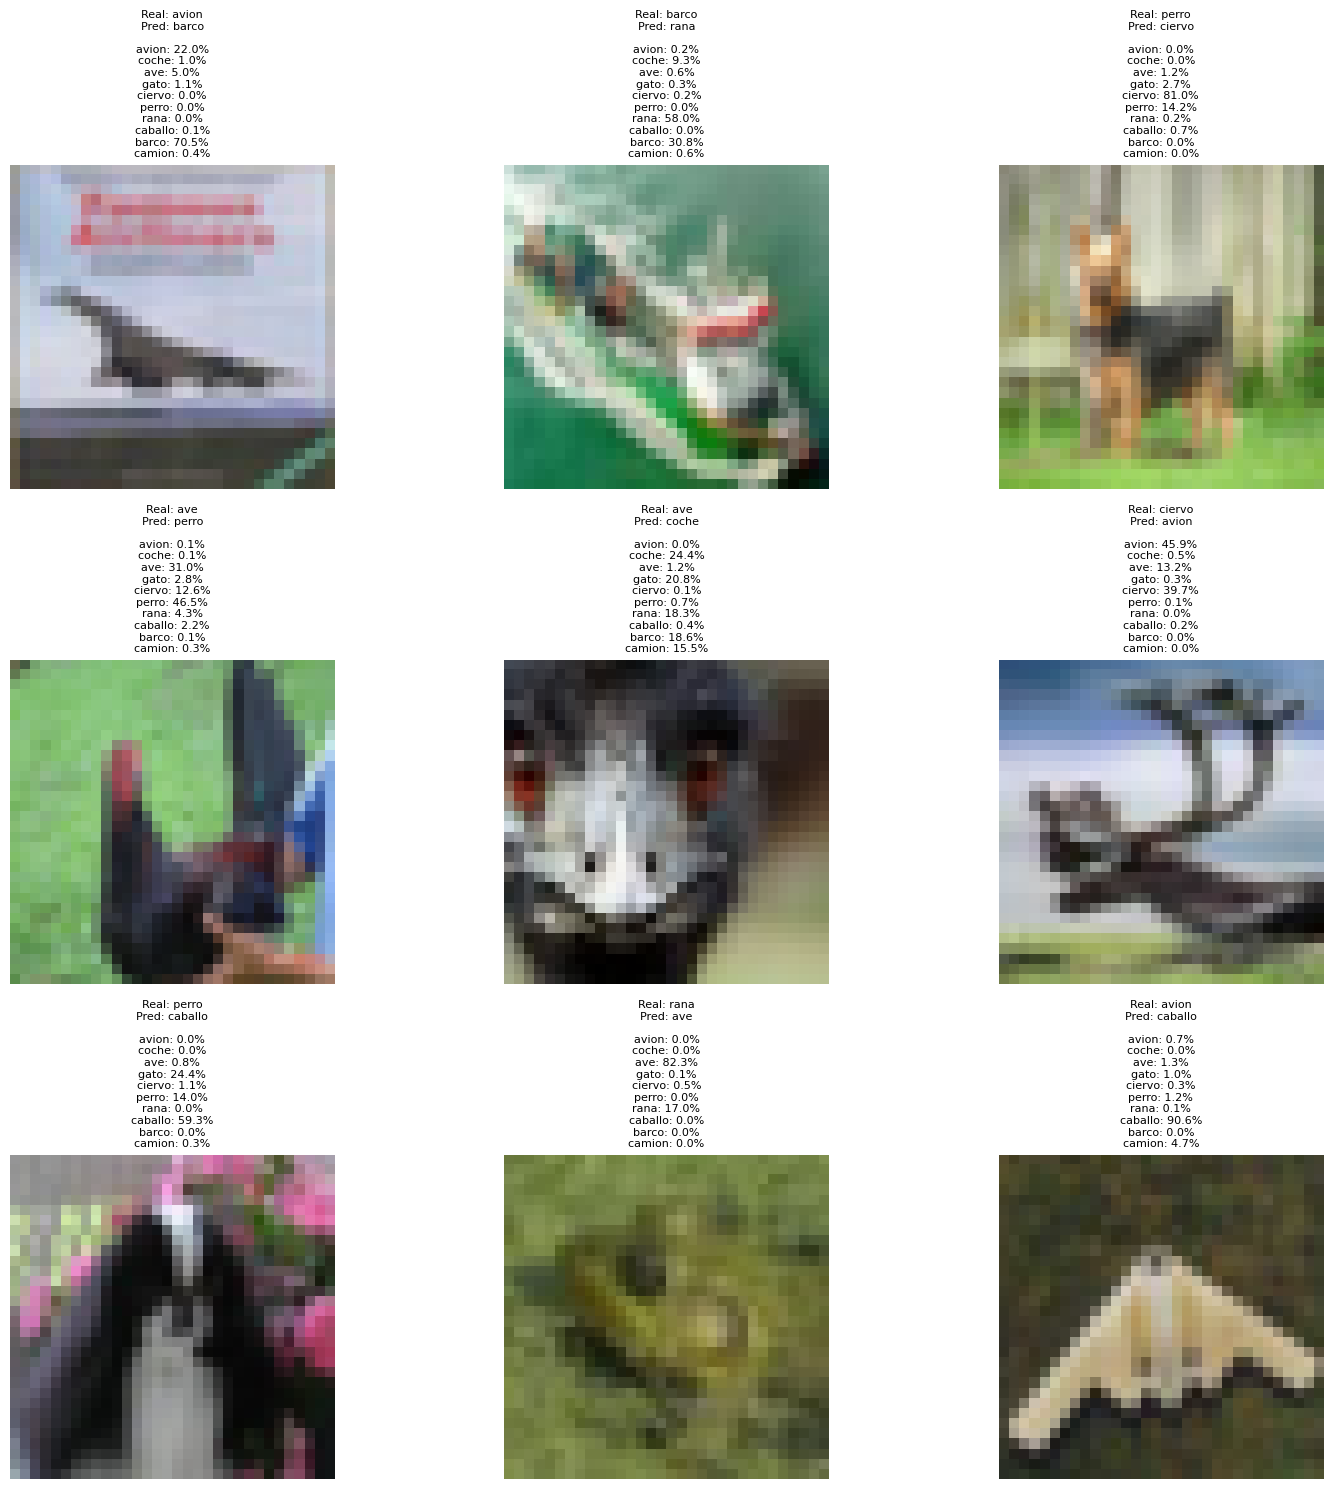

In [20]:
incorrect_idxs = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15, 15))
for i, idx in enumerate(incorrect_idxs[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.axis('off')

    pred_probs = y_pred_probs[idx] * 100
    prob_text = "\n".join([
        f"{MAP_ELEMENTS[i]}: {prob:.1f}%" for i, prob in enumerate(pred_probs)
    ])

    plt.title(f"Real: {MAP_ELEMENTS[y_true[idx]]}\nPred: {MAP_ELEMENTS[y_pred[idx]]}\n\n{prob_text}",
              fontsize=8)

plt.tight_layout()
plt.show()


Como podemos ver, en casi cada una de las imágenes la predicción real es la segunda en los porcentajes de predicción. Esto nos da a entender que el modelo si comprende las relaciones entre las imágenes y los labels pero comete pequeños errores que pueden ser solucionados mediante un modelo más complejo o transfer learning.  

### Preentrenados

No he conseguido hacerlo con modelos preentrenados (Transfer learning) ya que para ello hay que redimensionar las imágenes y con colab no hay suficiente RAM para hacerlo.

#### DenseNet

In [11]:
def preprocess_data(X, Y):
    X = K.applications.densenet.preprocess_input(X.astype('float32'))
    Y = K.utils.to_categorical(Y, 10)
    return X, Y

X_train, Y_train = preprocess_data(X_train, Y_train)
X_test, Y_test = preprocess_data(X_test, Y_test)

def resize_batch(x):
    return tf.image.resize(x, [224, 224])

X_train = resize_batch(X_train).numpy()
X_test = resize_batch(X_test).numpy()

ResourceExhaustedError: {{function_node __wrapped__ResizeBilinear_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[50000,224,224,3] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:ResizeBilinear] name: 

In [ ]:
inputs = K.Input(shape=(224, 224, 3))

base_model = K.applications.DenseNet121(include_top=False,
                                        weights='imagenet',
                                        input_tensor=inputs)
base_model.trainable = False

x = K.layers.GlobalAveragePooling2D()(base_model.output)
x = K.layers.Dense(256, activation='relu')(x)
x = K.layers.Dropout(0.3)(x)
outputs = K.layers.Dense(10, activation='softmax')(x)

model = K.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=K.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    batch_size=64,
    epochs=10,
    verbose=1
)

In [ ]:
loss, acc = model.evaluate(X_test, Y_test, batch_size=128)
print(f"\nTest Accuracy: {acc:.4f} | Loss: {loss:.4f}")

In [ ]:
y_pred = model.predict(X_test, batch_size=128)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(Y_test, axis=1)

labels = ['avion', 'coche', 'ave', 'gato', 'ciervo',
          'perro', 'rana', 'caballo', 'barco', 'camion']

print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=labels))

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()


plot_history(history)